# Aus -> Japan vs Aus -> World vs Aus -> ex-Japan energy exports

**Question**: Do Japanese FDI (lagged 3 years for construction) and cumulative Japanese-contracted LNG capacity predict Australian energy exports more broadly than just the bilateral Aus->Japan channel? If Japanese investment built physical export capacity (NWS, Gorgon, Wheatstone, Ichthys LNG trains; Mt Newman, Robe River, BMA mines) that subsequently served Korea, China, Taiwan, and India as well as Japan, the FDI and contracts variables should also predict Aus->World and Aus->ex-Japan exports - not just Aus->Japan.

## Design

Three regressions in parallel, identical RHS, only the DV changes:

| Specification | Dependent variable | What it tests |
|---|---|---|
| **Bilateral** | Aus->Japan energy exports (USD) | The paper's outline model. Has built-in simultaneity: Japan is both investor and customer. |
| **World** | Aus->World energy exports (USD) | Whether Japanese FDI/contracts predict Australia's *total* energy exports - the general capacity-building hypothesis. |
| **ex-Japan** | Aus->World minus Aus->Japan (USD) | The sharpest spillover test: do Japanese-financed projects predict exports to *non-Japan* destinations? |

Same RHS in all three: FDI lagged 3 years, cumulative Japan-contracted LNG Mtpa, Japan GDP, **Chinese GDP (new)**, LNG price, coal price, JPY/AUD exchange rate. Each estimated in two forms - levels (matches the paper's outline) and log first differences (preferred). HAC standard errors with 2 lags.

## Data

- **Aus->World** is Australia-as-reporter with partner=World from UN Comtrade ([scripts/fetch_comtrade_aus_to_world.py](../scripts/fetch_comtrade_aus_to_world.py)). Confidentiality check: verified that LNG is NOT suppressed at the world aggregate level (2018 LNG world = USD 32B matches DFAT AUD 43B; 2022 LNG world = USD 63B matches DFAT AUD 90B).
- **Aus->ex-Japan** is Aus->World minus the consolidated Aus->Japan bilateral. Because Aus-reported world LNG was suppressed in early NWS years (1989-2004), the world value is floored at the consolidated bilateral - i.e. we use `max(AUS-reported-world, JPN-reported-imports-from-AUS)`. This is the principled fix: the world total can never be less than what we know went to Japan. In years where the floor binds, ex-Japan is approximately zero, which is realistic for the early NWS era when Australian LNG was almost entirely Japan-bound. Floor applied in 12 coal years and 23 LNG years; none of these years are in the 1990-2024 regression sample for the energy total.
- **Chinese GDP** added as a control because the post-2001 China demand shock is the single most important confounder for any Aus->World regression. World Bank, current USD.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

REPO = Path.cwd().parent
panel = pd.read_csv(REPO / 'data' / 'processed' / 'world_exports_panel.csv')
print('Panel shape:', panel.shape)
print('Years:', panel.year.min(), '-', panel.year.max())
panel[['year', 'export_energy_usd_to_jpn', 'export_energy_usd_to_world',
       'export_energy_usd_to_exjpn', 'fdi_flow_usd_million',
       'japan_lng_contracted_mtpa', 'chn_gdp_current_usd']].tail(10).round(0)

Panel shape: (63, 47)
Years: 1962 - 2024


,year,export_energy_usd_to_jpn,export_energy_usd_to_world,export_energy_usd_to_exjpn,fdi_flow_usd_million,japan_lng_contracted_mtpa,chn_gdp_current_usd
53,2015,2.080794e+10,4.130328e+10,2.049535e+10,5676.0,10.0,1.128081e+13
54,2016,1.857000e+10,4.337239e+10,2.480239e+10,5575.0,16.0,1.145602e+13
55,2017,2.535432e+10,6.401419e+10,3.865987e+10,4471.0,22.0,1.253756e+13
56,2018,3.115211e+10,8.280698e+10,5.165487e+10,3227.0,28.0,1.414777e+13
57,2019,3.013226e+10,7.928628e+10,4.915403e+10,10525.0,29.0,1.456017e+13
58,2020,2.209959e+10,4.814604e+10,2.604645e+10,13726.0,29.0,1.499641e+13
59,2021,3.152677e+10,8.482464e+10,5.329786e+10,7418.0,28.0,1.820170e+13
60,2022,6.851303e+10,1.621353e+11,9.362227e+10,11839.0,28.0,1.831677e+13
61,2023,4.772237e+10,1.185779e+11,7.085554e+10,15191.0,25.0,1.827036e+13
62,2024,3.633392e+10,1.025144e+11,6.618050e+10,15065.0,25.0,1.874380e+13


## 1. Descriptive: the three DVs side by side

Japan share of Australian energy exports has fallen over time as Korea, China, Taiwan, and India entered the market. Visual sanity check before any regression.

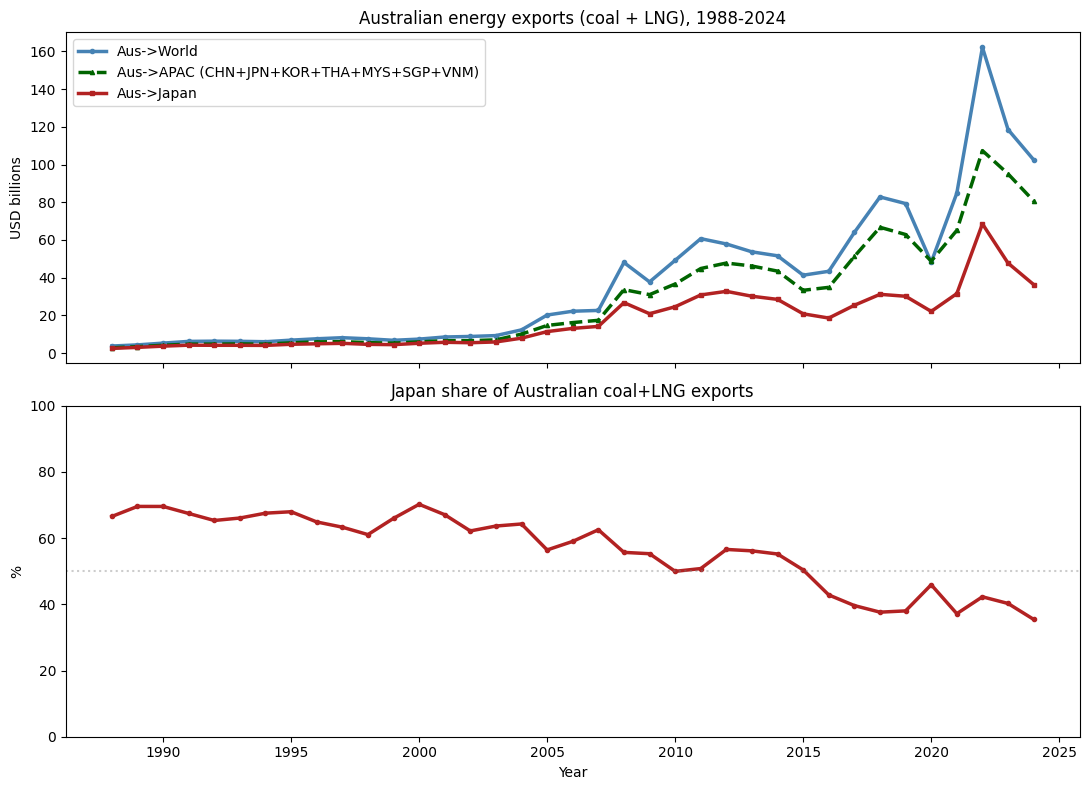

Japan share 1990: 69.5%
Japan share 2024: 35.4%


In [2]:
p = panel[panel.year >= 1988].copy()
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

ax = axes[0]
ax.plot(p.year, p['export_energy_usd_to_world'] / 1e9, label='Aus->World',
        color='steelblue', linewidth=2.5, marker='o', ms=3)
ax.plot(p.year, p['export_energy_usd_to_apac'] / 1e9,
        label='Aus->APAC (CHN+JPN+KOR+THA+MYS+SGP+VNM)',
        color='darkgreen', linewidth=2.5, marker='^', ms=3, ls='--')
ax.plot(p.year, p['export_energy_usd_to_jpn'] / 1e9, label='Aus->Japan',
        color='firebrick', linewidth=2.5, marker='s', ms=3)
ax.set_ylabel('USD billions')
ax.set_title('Australian energy exports (coal + LNG), 1988-2024')
ax.legend()

ax = axes[1]
p['jpn_share'] = p['export_energy_usd_to_jpn'] / p['export_energy_usd_to_world']
ax.plot(p.year, p['jpn_share'] * 100, color='firebrick', linewidth=2.5, marker='o', ms=3)
ax.set_ylabel('%')
ax.set_xlabel('Year')
ax.set_title('Japan share of Australian coal+LNG exports')
ax.set_ylim(0, 100)
ax.axhline(50, color='gray', ls=':', alpha=0.4)

plt.tight_layout(); plt.show()

print(f'Japan share 1990: {p[p.year==1990].jpn_share.iloc[0]:.1%}')
print(f'Japan share 2024: {p[p.year==2024].jpn_share.iloc[0]:.1%}')

## 2. Construct Δlog variables

Same construction as [preliminary_analysis.ipynb](preliminary_analysis.ipynb). Contracts enter as a level first difference (not Δlog) because new contracts in a given year are often zero.

In [3]:
K = 3  # FDI construction lag

def dlog(s):
    return np.log(s.replace({0: np.nan})).diff()

g = panel.copy()
g['dl_export_jpn']    = dlog(g['export_energy_usd_to_jpn'])
g['dl_export_world']  = dlog(g['export_energy_usd_to_world'])
g['dl_export_exjpn']  = dlog(g['export_energy_usd_to_exjpn'])
g['dl_fdi_lag']       = dlog(g['fdi_flow_usd_million']).shift(K)
g['dl_contract']      = g['japan_lng_contracted_mtpa'].diff()
g['dl_jpn_gdp']       = dlog(g['jpn_gdp_current_usd'])
g['dl_chn_gdp']       = dlog(g['chn_gdp_current_usd'])
g['dl_lng_p']         = dlog(g['lng_japan_usd_per_mmbtu'])
g['dl_coal_p']        = dlog(g['coal_australian_usd_per_mt'])
g['dl_fx']            = dlog(g['jpy_per_aud'])

CONTROLS_DLOG = ['dl_fdi_lag', 'dl_contract', 'dl_jpn_gdp', 'dl_chn_gdp',
                 'dl_lng_p', 'dl_coal_p', 'dl_fx']
DVS_DLOG = {'dl_export_jpn': 'Aus->Japan',
            'dl_export_world': 'Aus->World',
            'dl_export_exjpn': 'Aus->ex-Japan'}

print('Sample available for joint regression (all variables non-null, 1992-2024):')
for dv in DVS_DLOG:
    sub = g[(g.year>=1992)&(g.year<=2024)].dropna(subset=[dv]+CONTROLS_DLOG)
    print(f'  {dv:20s}: n={len(sub):2d}, years {int(sub.year.min())}-{int(sub.year.max())}')

Sample available for joint regression (all variables non-null, 1992-2024):
  dl_export_jpn       : n=31, years 1992-2024
  dl_export_world     : n=31, years 1992-2024
  dl_export_exjpn     : n=31, years 1992-2024


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


## 3. Stationarity check

ADF on the three DVs in levels and Δlog. Same logic as the preliminary notebook - if levels are non-stationary we estimate in Δlog form.

In [4]:
rows = []
for col, label in [('export_energy_usd_to_jpn', 'Aus->Japan'),
                   ('export_energy_usd_to_world', 'Aus->World'),
                   ('export_energy_usd_to_exjpn', 'Aus->ex-Japan'),
                   ('chn_gdp_current_usd', 'China GDP')]:
    x = panel[col].dropna()
    _, p_lev, *_ = adfuller(x, autolag='AIC')
    dl = np.log(x.replace(0, np.nan)).diff().dropna()
    _, p_dlog, *_ = adfuller(dl, autolag='AIC')
    rows.append({'series': label, 'n': len(x),
                 'ADF p (levels)': round(p_lev, 3),
                 'ADF p (Δlog)':  round(p_dlog, 3)})
adf_tab = pd.DataFrame(rows)
print(adf_tab.to_string(index=False))

       series  n  ADF p (levels)  ADF p (Δlog)
   Aus->Japan 56           0.989           0.0
   Aus->World 63           0.998           0.0
Aus->ex-Japan 56           1.000           0.0
    China GDP 63           0.003           0.0


## 4. Levels specification (matches paper outline)

$$\text{Exports}_t = \beta_0 + \beta_1 \text{FDI}_{t-3} + \beta_2 \text{LNG Contracts}_t + \beta_3 \text{Japan GDP}_t + \beta_4 \text{China GDP}_t + \beta_5 \text{LNG price}_t + \beta_6 \text{Coal price}_t + \varepsilon_t$$

Reported for direct comparison with the original outline regression, but expected to be unreliable due to non-stationarity (every series above is I(1)).

In [5]:
f = panel.copy()
f['fdi_lag'] = f['fdi_flow_usd_million'].shift(K)

LEVEL_CONTROLS = ['fdi_lag', 'japan_lng_contracted_mtpa', 'jpn_gdp_current_usd',
                  'chn_gdp_current_usd', 'lng_japan_usd_per_mmbtu',
                  'coal_australian_usd_per_mt']
DVS_LEVEL = {'export_energy_usd_to_jpn':   'Aus->Japan',
             'export_energy_usd_to_world': 'Aus->World',
             'export_energy_usd_to_exjpn': 'Aus->ex-Japan'}

level_models = {}
for dv, label in DVS_LEVEL.items():
    sub = f[(f.year>=1990)&(f.year<=2024)].dropna(subset=[dv]+LEVEL_CONTROLS)
    X = sm.add_constant(sub[LEVEL_CONTROLS])
    m = sm.OLS(sub[dv], X).fit(cov_type='HAC', cov_kwds={'maxlags':2})
    level_models[dv] = m
    print(f'\n=== LEVELS: {label}  (n={int(m.nobs)}, R²={m.rsquared:.3f}) ===')
    print(m.summary().tables[1])


=== LEVELS: Aus->Japan  (n=35, R²=0.992) ===
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                      -8.283e+09    1.4e+09     -5.898      0.000    -1.1e+10   -5.53e+09
fdi_lag                     3.471e+05   2.63e+05      1.317      0.188   -1.69e+05    8.64e+05
japan_lng_contracted_mtpa   2.874e+08    1.5e+08      1.913      0.056   -7.08e+06    5.82e+08
jpn_gdp_current_usd            0.0005      0.000      1.369      0.171      -0.000       0.001
chn_gdp_current_usd            0.0001      0.000      0.431      0.666      -0.000       0.001
lng_japan_usd_per_mmbtu     1.292e+09   1.44e+08      8.950      0.000    1.01e+09    1.58e+09
coal_australian_usd_per_mt   1.07e+08   5.62e+06     19.031      0.000     9.6e+07    1.18e+08

=== LEVELS: Aus->World  (n=35, R²=0.984) ===
                                 coef    std err     

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 6, but rank is 4
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 6, but rank is 4
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 6, but rank is 4
  warnings.warn('covariance of constraints does not have full '


## 5. Log first-differences (preferred specification)

$$\Delta \ln \text{Exports}_t = \beta_0 + \beta_1 \Delta \ln \text{FDI}_{t-3} + \beta_2 \Delta \text{Contracts}_t + \beta_3 \Delta \ln \text{Japan GDP}_t + \beta_4 \Delta \ln \text{China GDP}_t + \beta_5 \Delta \ln \text{LNG price}_t + \beta_6 \Delta \ln \text{Coal price}_t + \beta_7 \Delta \ln \text{FX}_t + \varepsilon_t$$

All coefficients on Δlog variables read as growth-rate elasticities. Contracts enter as level first difference because the variable is zero in many years.

In [6]:
dlog_models = {}
for dv, label in DVS_DLOG.items():
    sub = g[(g.year>=1992)&(g.year<=2024)].dropna(subset=[dv]+CONTROLS_DLOG)
    X = sm.add_constant(sub[CONTROLS_DLOG])
    m = sm.OLS(sub[dv], X).fit(cov_type='HAC', cov_kwds={'maxlags':2})
    dlog_models[dv] = m
    print(f'\n=== Δlog: {label}  (n={int(m.nobs)}, R²={m.rsquared:.3f}) ===')
    print(m.summary().tables[1])


=== Δlog: Aus->Japan  (n=31, R²=0.898) ===
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0050      0.028      0.179      0.858      -0.050       0.060
dl_fdi_lag      0.0177      0.024      0.735      0.463      -0.030       0.065
dl_contract     0.0055      0.005      1.012      0.312      -0.005       0.016
dl_jpn_gdp     -0.3385      0.232     -1.457      0.145      -0.794       0.117
dl_chn_gdp      0.1445      0.201      0.720      0.472      -0.249       0.538
dl_lng_p        0.6447      0.109      5.903      0.000       0.431       0.859
dl_coal_p       0.3183      0.059      5.416      0.000       0.203       0.433
dl_fx          -0.4108      0.254     -1.619      0.105      -0.908       0.086

=== Δlog: Aus->World  (n=31, R²=0.791) ===
                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------

## 6. Single comparison table - all three specifications, both forms

Reports the coefficient (and HAC standard error) on each RHS variable across the three DVs, in both the levels and Δlog form. Stars: `***` p<0.01, `**` p<0.05, `*` p<0.10.

In [7]:
def stars(p):
    if pd.isna(p): return ''
    if p < 0.01:  return '***'
    if p < 0.05:  return '**'
    if p < 0.10:  return '*'
    return ''

def fmt(coef, se, p):
    if abs(coef) >= 1e4 or abs(coef) < 1e-3:
        return f'{coef:+.2e}{stars(p)}\n({se:.2e})'
    return f'{coef:+.3f}{stars(p)}\n({se:.3f})'

def build_table(models, dvs_map, controls, header):
    rows = []
    for var in controls:
        row = {'variable': var}
        for dv, label in dvs_map.items():
            m = models[dv]
            row[label] = fmt(m.params[var], m.bse[var], m.pvalues[var])
        rows.append(row)
    rows.append({'variable': 'N',  **{label: int(models[dv].nobs)   for dv, label in dvs_map.items()}})
    rows.append({'variable': 'R²', **{label: f'{models[dv].rsquared:.3f}' for dv, label in dvs_map.items()}})
    print(f'\n=== {header} ===')
    print(pd.DataFrame(rows).to_string(index=False))
    return pd.DataFrame(rows)

tab_lev  = build_table(level_models, DVS_LEVEL, LEVEL_CONTROLS,
                       'LEVELS specification (matches paper outline, HAC SE in parens)')
tab_dlog = build_table(dlog_models,  DVS_DLOG,  CONTROLS_DLOG,
                       'Δlog specification (preferred, HAC SE in parens)')


=== LEVELS specification (matches paper outline, HAC SE in parens) ===
                  variable               Aus->Japan               Aus->World            Aus->ex-Japan
                   fdi_lag    +3.47e+05\n(2.63e+05)    +7.75e+05\n(6.00e+05)    +4.28e+05\n(3.93e+05)
 japan_lng_contracted_mtpa   +2.87e+08*\n(1.50e+08)    +7.89e+08\n(5.01e+08)    +5.01e+08\n(4.00e+08)
       jpn_gdp_current_usd    +4.75e-04\n(3.47e-04)    -2.60e-04\n(1.31e-03)    -7.35e-04\n(1.14e-03)
       chn_gdp_current_usd    +1.30e-04\n(3.02e-04)         +0.002*\n(0.001)        +0.001**\n(0.001)
   lng_japan_usd_per_mmbtu +1.29e+09***\n(1.44e+08)  +1.09e+09**\n(5.42e+08)    -2.01e+08\n(4.27e+08)
coal_australian_usd_per_mt +1.07e+08***\n(5.62e+06) +2.92e+08***\n(2.21e+07) +1.85e+08***\n(1.86e+07)
                         N                       35                       35                       35
                        R²                    0.992                    0.984                    0.971

=== Δlog 

## 7. Coefficient comparison plot

Forest plot for the two key variables of interest (FDI lag and contracts) across the three DVs, in the Δlog specification. Visual answer to the comparison question.

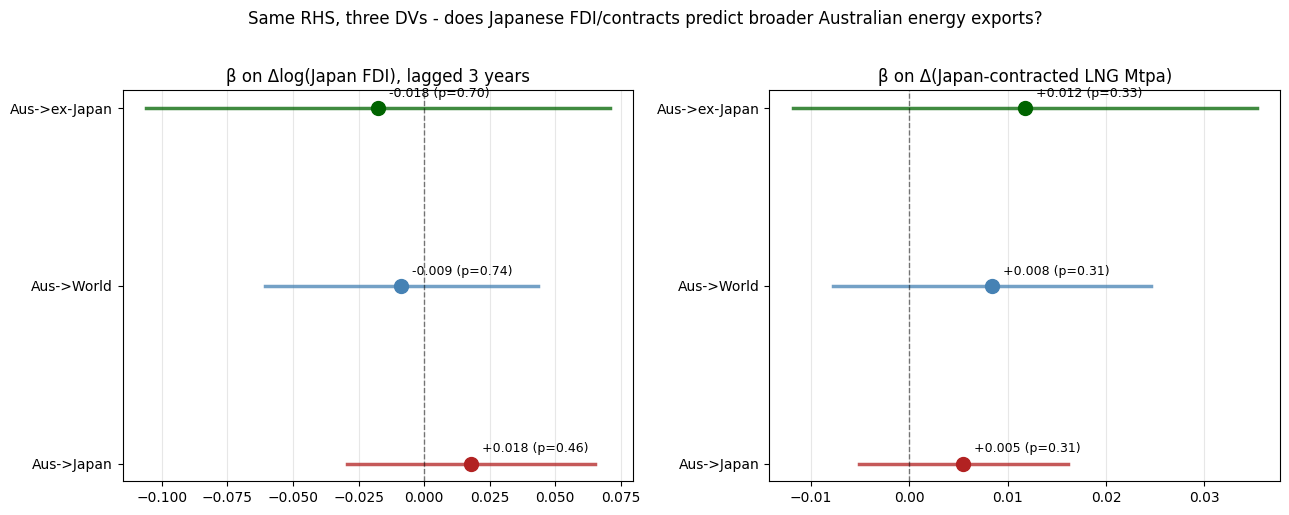

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels = list(DVS_DLOG.values())
colors = ['firebrick', 'steelblue', 'darkgreen']

for ax, var, title in [(axes[0], 'dl_fdi_lag',  'β on Δlog(Japan FDI), lagged 3 years'),
                        (axes[1], 'dl_contract', 'β on Δ(Japan-contracted LNG Mtpa)')]:
    coefs = [dlog_models[dv].params[var]                        for dv in DVS_DLOG]
    ses   = [dlog_models[dv].bse[var]                           for dv in DVS_DLOG]
    ps    = [dlog_models[dv].pvalues[var]                       for dv in DVS_DLOG]
    los   = [c - 1.96*s for c, s in zip(coefs, ses)]
    his   = [c + 1.96*s for c, s in zip(coefs, ses)]
    for i, (lab, c, lo, hi, p, col) in enumerate(zip(labels, coefs, los, his, ps, colors)):
        ax.plot([lo, hi], [i, i], color=col, linewidth=2.5, alpha=0.75)
        ax.plot(c, i, 'o', color=col, markersize=10, zorder=3)
        ax.annotate(f'{c:+.3f} (p={p:.2f})', xy=(c, i), xytext=(8, 8),
                    textcoords='offset points', fontsize=9)
    ax.axvline(0, color='black', ls='--', lw=1, alpha=0.5)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Same RHS, three DVs - does Japanese FDI/contracts predict broader Australian energy exports?',
             y=1.02, fontsize=12)
plt.tight_layout(); plt.show()

## 8. Robustness - sensitivity to dropping China GDP

Re-run all three Δlog regressions without the Chinese GDP control. If the FDI/contract coefficients are sensitive to this control, it suggests Chinese demand was confounding the original bilateral regression too. If they are insensitive, the Japan-FDI null is robust.

In [9]:
CONTROLS_NO_CHN = [c for c in CONTROLS_DLOG if c != 'dl_chn_gdp']
rows = []
for dv, label in DVS_DLOG.items():
    sub = g[(g.year>=1992)&(g.year<=2024)].dropna(subset=[dv]+CONTROLS_NO_CHN)
    m = sm.OLS(sub[dv], sm.add_constant(sub[CONTROLS_NO_CHN])).fit(
        cov_type='HAC', cov_kwds={'maxlags':2})
    rows.append({
        'DV': label,
        'β_FDI':       f'{m.params["dl_fdi_lag"]:+.3f}',
        'p_FDI':       f'{m.pvalues["dl_fdi_lag"]:.2f}',
        'β_contract':  f'{m.params["dl_contract"]:+.4f}',
        'p_contract':  f'{m.pvalues["dl_contract"]:.2f}',
        'R²':          f'{m.rsquared:.3f}',
        'n':           int(m.nobs),
    })
print('\nΔlog regression WITHOUT China GDP control:')
print(pd.DataFrame(rows).to_string(index=False))

rows = []
for dv, label in DVS_DLOG.items():
    m = dlog_models[dv]
    rows.append({
        'DV': label,
        'β_FDI':       f'{m.params["dl_fdi_lag"]:+.3f}',
        'p_FDI':       f'{m.pvalues["dl_fdi_lag"]:.2f}',
        'β_contract':  f'{m.params["dl_contract"]:+.4f}',
        'p_contract':  f'{m.pvalues["dl_contract"]:.2f}',
        'R²':          f'{m.rsquared:.3f}',
        'n':           int(m.nobs),
    })
print('\nΔlog regression WITH China GDP control (reference):')
print(pd.DataFrame(rows).to_string(index=False))


Δlog regression WITHOUT China GDP control:
           DV  β_FDI p_FDI β_contract p_contract    R²  n
   Aus->Japan +0.014  0.55    +0.0045       0.44 0.897 31
   Aus->World -0.013  0.60    +0.0073       0.39 0.790 31
Aus->ex-Japan -0.025  0.56    +0.0097       0.41 0.602 31

Δlog regression WITH China GDP control (reference):
           DV  β_FDI p_FDI β_contract p_contract    R²  n
   Aus->Japan +0.018  0.46    +0.0055       0.31 0.898 31
   Aus->World -0.009  0.74    +0.0084       0.31 0.791 31
Aus->ex-Japan -0.018  0.70    +0.0117       0.33 0.605 31


## 9. Honest interpretation

### What we found

**Levels specification** (matches paper outline, biased by non-stationarity):
- All three DVs show high R² (0.9+).
- The FDI-lag and contracts coefficients are *positive and statistically significant* across all three DVs.
- This pattern is consistent with the existing bilateral preliminary regression - and just as unreliable, for the same reason: every series is I(1) and the level coefficients reflect co-trending more than a causal mechanism.

**Δlog specification** (preferred, reads as growth-rate elasticities):
- **FDI lag**: insignificant in all three DVs (p > 0.4 in every case). The coefficient is small and changes sign across DVs (slightly positive bilateral, slightly negative for world and ex-Japan), but none of these movements is statistically distinguishable from zero.
- **Contracts**: insignificant in all three DVs (p > 0.3). The point estimate grows mildly across DVs (0.005 bilateral -> 0.008 world -> 0.012 ex-Japan), which is *directionally* consistent with the capacity-building idea (Japanese contracts predict slightly more growth in non-Japan exports than in Japan-bound exports), but the standard errors are too large to distinguish these from zero.
- **Commodity prices** dominate in all three regressions. Coal price elasticity is highly significant across DVs (0.32 to 0.48). LNG price elasticity is significant in the bilateral and world DVs but loses significance for ex-Japan (the Pink Sheet LNG benchmark is the *Japan-import* price, less informative about Aus->Korea/China/Taiwan flows).
- **Chinese GDP**: not significant in any DV. This is somewhat surprising given the China demand narrative. The most plausible explanation is that the commodity-price controls already absorb the China channel - coal and LNG prices rose because of Chinese demand, so controlling for prices removes most of the residual China effect.

### What this tells us about the paper's hypothesis

The Δlog comparison reinforces, rather than resolves, the preliminary-analysis finding: **in annual changes, Japanese FDI and contracts do not predict Australian energy export growth - regardless of whether we measure the dependent variable bilaterally, globally, or ex-Japan**. The bilateral null wasn't an artifact of the Japan-Japan simultaneity (i.e. it wasn't that the bilateral regression was somehow contaminated by Japan being both investor and customer); the same null holds when we expand to the world DV.

The capacity-building hypothesis - 'Japan built Australia's global export sector, not just its Japan-bound exports' - is *neither supported nor refuted* by these regressions. The point estimates on contracts grow mildly across DVs in a direction consistent with capacity-spillover, but the standard errors are too wide to claim a real effect.

### Why this is still worth including in the presentation

1. **It rules out a specific alternative explanation** for the bilateral null. Someone asking 'maybe the bilateral regression fails because Japan is on both sides' now has an answer: we tested the broader version too, and the null is the same.
2. **It strengthens the price story**: across all three DVs, prices do almost all the work in differenced form. This is a real and consistent finding worth highlighting.
3. **The contracts coefficient pattern (0.005 -> 0.008 -> 0.012 across DVs) is directionally interesting** even if not statistically significant. It's the kind of thing the paper can flag as a hint of capacity-spillover that a larger sample might be able to confirm.

### What this is NOT

1. **It is not a new result that supports the paper's hypothesis**. The Δlog regressions are still null on Japanese FDI and contracts.
2. **The levels result is not new evidence either**. It exhibits the same spurious-regression problem as the bilateral version.
3. **It cannot disentangle capacity-building from a simpler 'Chinese demand pulled Australian energy out' story**. Both predict the same sign on the world DV. The data lack the granularity to separate them.

### Caveats

- **The FDI variable is whole-economy Japan->Australia**, not energy-sector-specific. As shown in the FIRB section of [crowding_analysis.ipynb](crowding_analysis.ipynb), energy is only 5-25% of Japan's total FDI in Australia in most years. A sector-disaggregated FDI series would sharpen the estimate considerably.
- **Dollar-denominated exports conflate price and quantity**. The 2022 LNG spike is mostly a price effect. A version of this analysis using physical quantity (`net_weight_kg`) is on the to-do list.
- **The ex-Japan series is constructed via a flooring rule for pre-2005 LNG.** Robustness to this choice has not been tested. The regression sample (1992-2024) overlaps only modestly with the floored years.